Shape of dataset: (1436, 11)

Column names:
 ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB

Statistical Summary:
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436

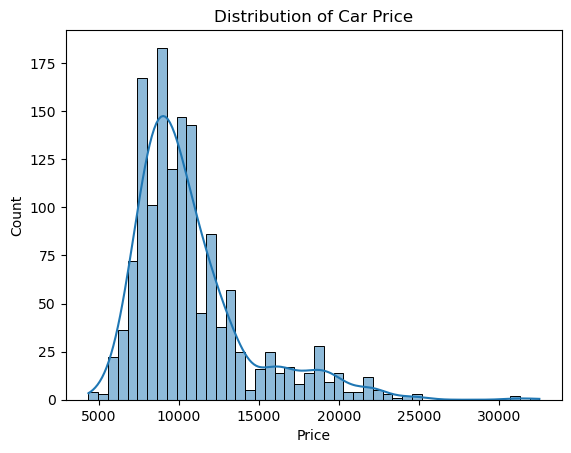

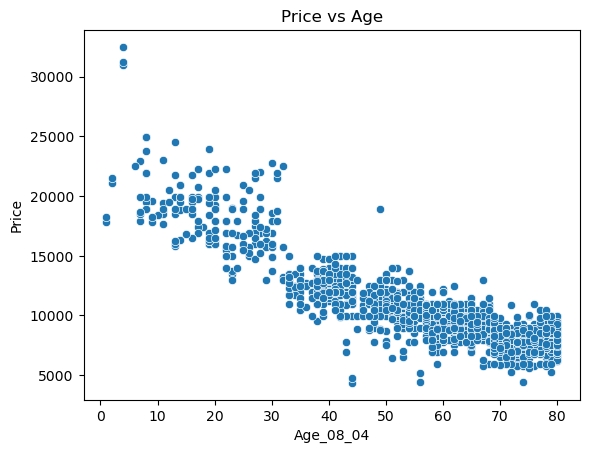

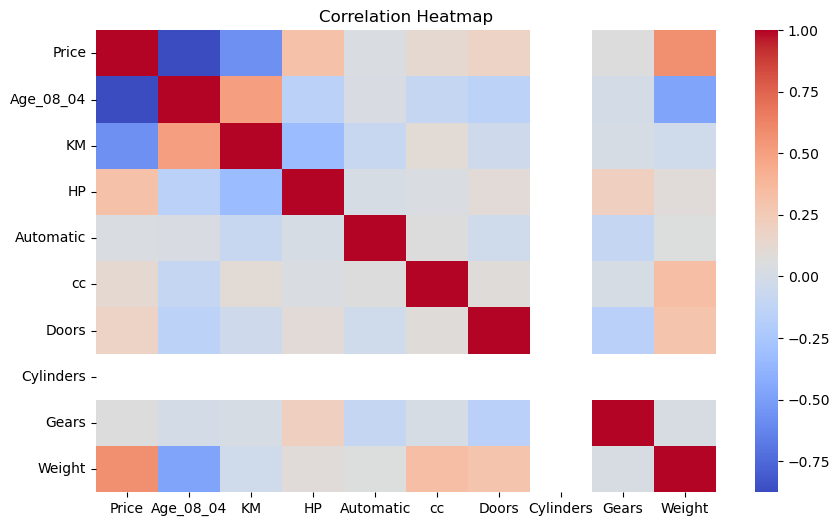

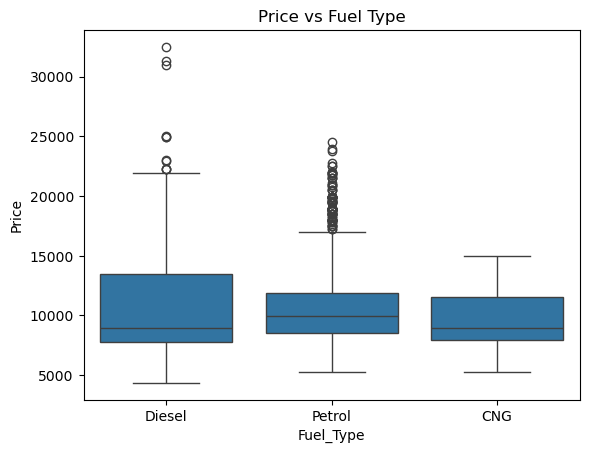

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Clean column names (removes extra spaces, fixes case issues)
df.columns = df.columns.str.strip()

# Display basic information
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nDataset Info:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# --------- EDA VISUALIZATION ---------

# Distribution of target variable (Price)
if "Price" in df.columns:
    plt.figure()
    sns.histplot(df["Price"], kde=True)
    plt.title("Distribution of Car Price")
    plt.show()

    # Price vs Age
    plt.figure()
    sns.scatterplot(x=df["Age_08_04"], y=df["Price"])
    plt.title("Price vs Age")
    plt.show()
else:
    print("\n 'Price' column not found. Please check target column name.")

# Correlation heatmap (only numeric columns)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Categorical vs Price (if Fuel_Type exists)
if "Fuel_Type" in df.columns and "Price" in df.columns:
    plt.figure()
    sns.boxplot(x="Fuel_Type", y="Price", data=df)
    plt.title("Price vs Fuel Type")
    plt.show()


In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Clean column names
df.columns = df.columns.str.strip()

# --------- FEATURE EXAMINATION ---------

# 1. List of features
print("Features in the dataset:\n")
print(df.columns.tolist())

# 2. Data types of features
print("\nData Types of Features:\n")
print(df.dtypes)

# 3. Separate numerical and categorical features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Features:\n", numerical_features)
print("\nCategorical Features:\n", categorical_features)

# 4. Summary statistics for numerical features
print("\nSummary Statistics (Numerical Features):\n")
print(df[numerical_features].describe())

# 5. Summary statistics for categorical features
if len(categorical_features) > 0:
    print("\nSummary Statistics (Categorical Features):\n")
    print(df[categorical_features].describe())


Features in the dataset:

['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Data Types of Features:

Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

Numerical Features:
 ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Categorical Features:
 ['Fuel_Type']

Summary Statistics (Numerical Features):

              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    

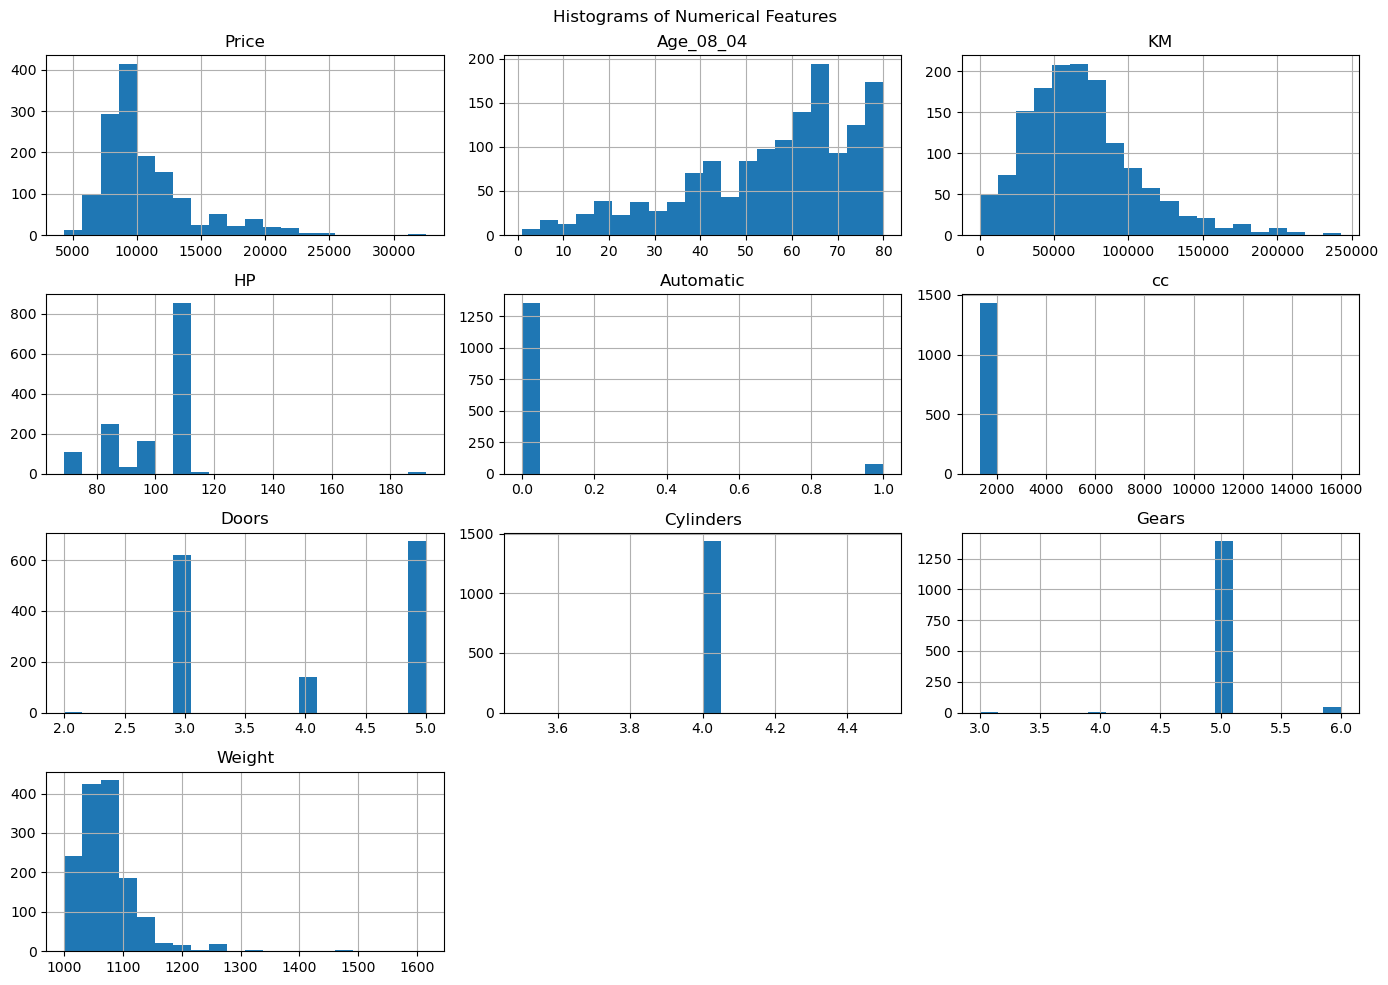

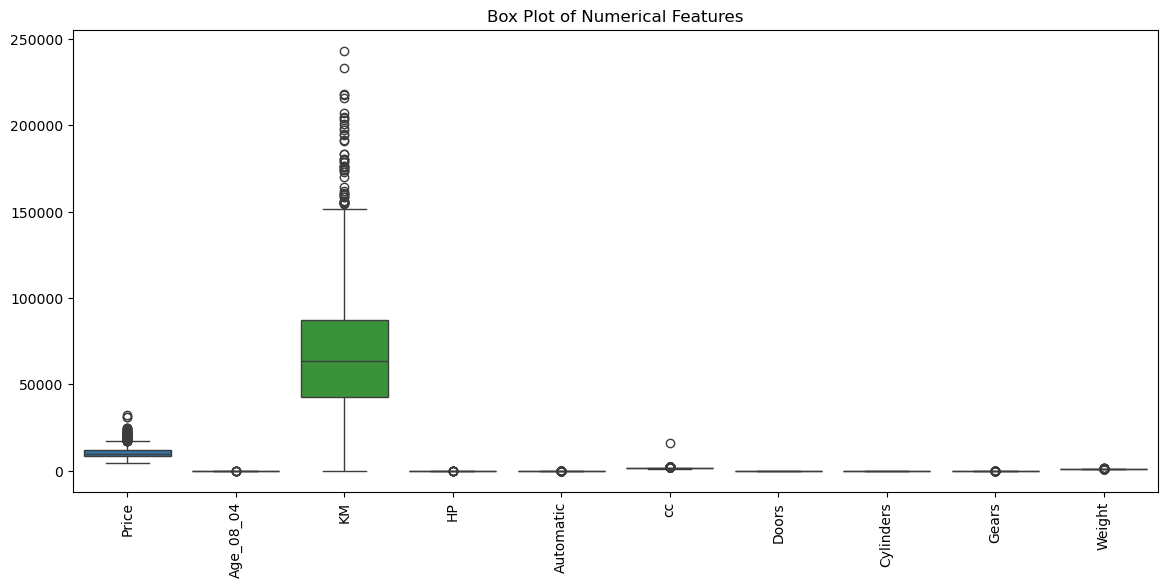

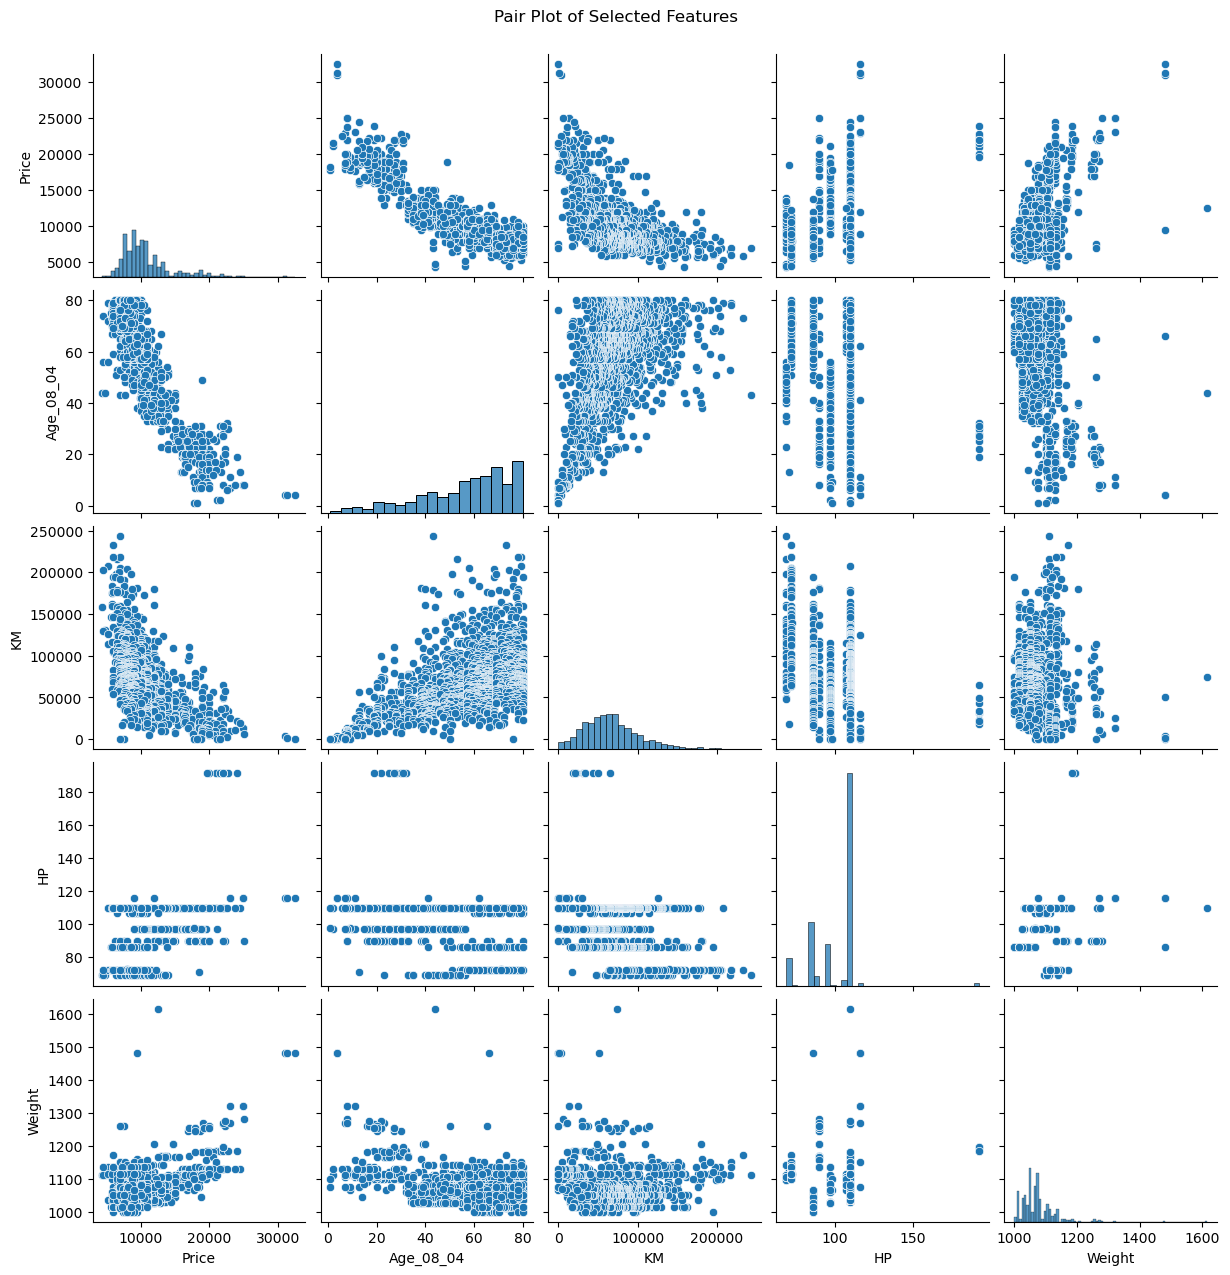

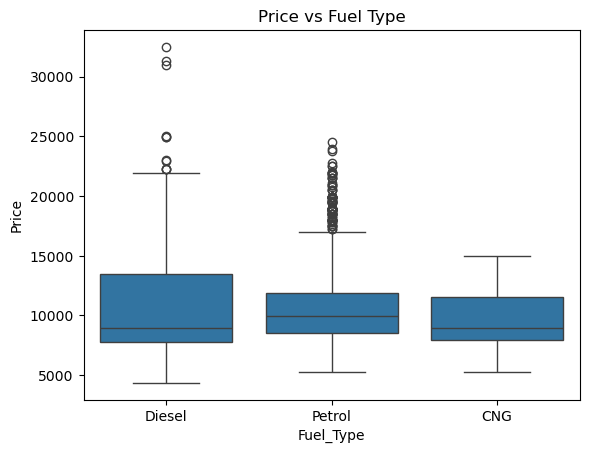

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Clean column names
df.columns = df.columns.str.strip()

# ---------- HISTOGRAMS (Distribution of Numerical Features) ----------
numerical_features = df.select_dtypes(include=np.number).columns

df[numerical_features].hist(figsize=(14,10), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

# ---------- BOX PLOTS (Outlier Detection) ----------
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numerical_features])
plt.xticks(rotation=90)
plt.title("Box Plot of Numerical Features")
plt.show()

# ---------- PAIR PLOT (Feature Relationships) ----------
selected_features = ["Price", "Age_08_04", "KM", "HP", "Weight"]
selected_features = [f for f in selected_features if f in df.columns]

sns.pairplot(df[selected_features])
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()

# ---------- CATEGORICAL vs NUMERICAL ----------
if "Fuel_Type" in df.columns and "Price" in df.columns:
    plt.figure()
    sns.boxplot(x="Fuel_Type", y="Price", data=df)
    plt.title("Price vs Fuel Type")
    plt.show()


In [6]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Check missing values before handling
print("Missing values before imputation:\n")
print(df.isnull().sum())

# Separate numerical and categorical columns
numerical_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(exclude=np.number).columns

# Impute numerical features with mean (SAFE METHOD)
df[numerical_features] = df[numerical_features].fillna(
    df[numerical_features].mean()
)

# Impute categorical features with mode (SAFE METHOD)
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values after handling
print("\nMissing values after imputation:\n")
print(df.isnull().sum())


Missing values before imputation:

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Missing values after imputation:

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [7]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Handle missing values (safe method)
numerical_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(exclude=np.number).columns

df[numerical_features] = df[numerical_features].fillna(
    df[numerical_features].mean()
)

for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

# --------- ENCODE CATEGORICAL VARIABLES ---------

# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Display encoded columns
print("Encoded feature columns:\n")
print(df_encoded.columns.tolist())


Encoded feature columns:

['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load Titanic train dataset
train_df = pd.read_csv("Titanic_train.csv")

# Clean column names
train_df.columns = train_df.columns.str.strip()

# Drop unnecessary columns
train_df = train_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# Handle missing values
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].mean())
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])

# Encode categorical variables
train_df = pd.get_dummies(train_df, columns=["Sex", "Embarked"], drop_first=True)

# Separate features and target
X = train_df.drop("Survived", axis=1)
y = train_df["Survived"]

# Feature Scaling (IMPORTANT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Logistic Regression model (increased max_iter)
model = LogisticRegression(max_iter=2000, solver="lbfgs")
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8100558659217877

Confusion Matrix:
 [[90 15]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load Titanic train dataset
df = pd.read_csv("Titanic_train.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Drop unnecessary columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical variables
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --------- MODEL TRAINING ---------

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully on training data.")


Logistic Regression model trained successfully on training data.


Accuracy : 0.8100558659217877
Precision: 0.7857142857142857
Recall   : 0.7432432432432432
F1-Score : 0.7638888888888888
ROC-AUC  : 0.8821106821106821


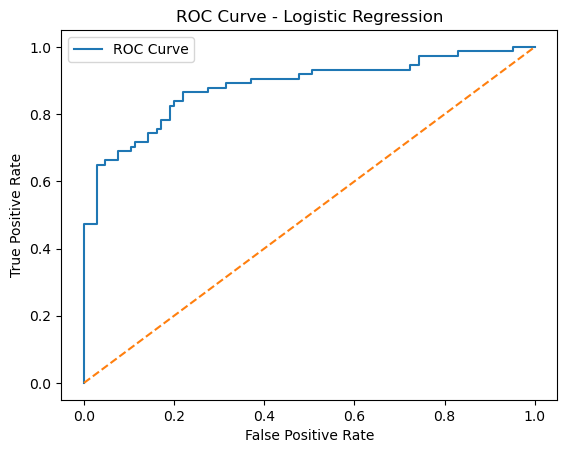

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Load Titanic train dataset
df = pd.read_csv("Titanic_train.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Drop unnecessary columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical variables
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Logistic Regression model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# --------- PERFORMANCE METRICS ---------

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_prob))

# --------- ROC CURVE ---------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load Titanic train dataset
df = pd.read_csv("Titanic_train.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Drop unnecessary columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical variables
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Logistic Regression model
model = LogisticRegression(max_iter=2000)
model.fit(X_scaled, y)

# --------- COEFFICIENT INTERPRETATION ---------

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)


      Feature  Coefficient
4        Fare     0.101841
6  Embarked_Q    -0.009214
3       Parch    -0.074089
7  Embarked_S    -0.183261
2       SibSp    -0.353025
1         Age    -0.504269
0      Pclass    -0.904079
5    Sex_male    -1.287816


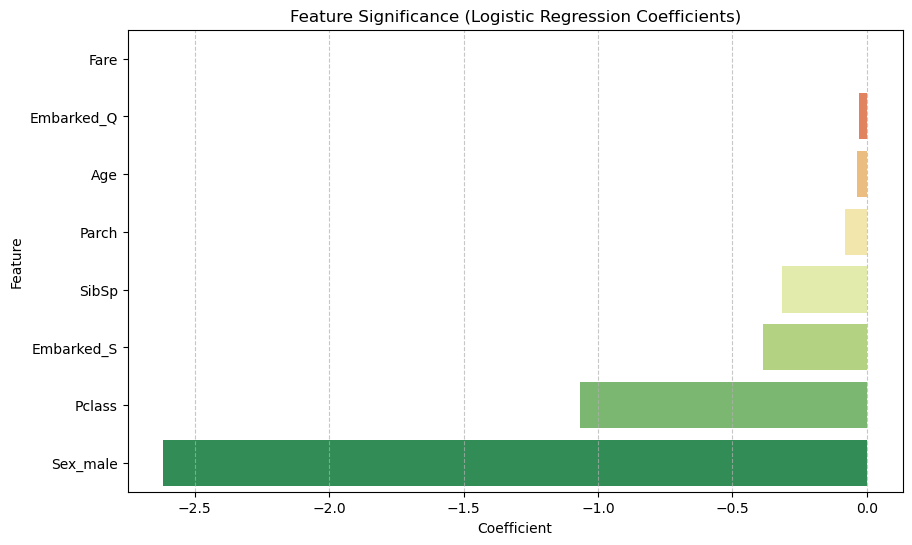


| Feature | Coefficient | Interpretation |
| :--- | :---: | :--- |
| **Fare** | $0.0022$ | Increases survival odds |
| **Embarked_Q** | $-0.0305$ | Decreases survival odds |
| **Age** | $-0.0382$ | Decreases survival odds |
| **Parch** | $-0.0795$ | Decreases survival odds |
| **SibSp** | $-0.3151$ | Decreases survival odds |
| **Embarked_S** | $-0.3846$ | Decreases survival odds |
| **Pclass** | $-1.0664$ | Decreases survival odds |
| **Sex_male** | $-2.6186$ | Decreases survival odds |


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Load the dataset
train_df = pd.read_csv('Titanic_train.csv')

# 2. Preprocessing
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

df = train_df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

# 3. Build Model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# 4. Extract Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# 5. Visualize (Fixed Seaborn Plot)
plt.figure(figsize=(10, 6))

# UPDATED LINE: Added hue='Feature' and legend=False to fix the warning
sns.barplot(x='Coefficient', y='Feature', data=importance, hue='Feature', palette='RdYlGn', legend=False)

plt.title('Feature Significance (Logistic Regression Coefficients)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Display Table with Math Formatting
from IPython.display import display, Markdown

table_md = """
| Feature | Coefficient | Interpretation |
| :--- | :---: | :--- |
"""
for _, row in importance.iterrows():
    table_md += f"| **{row['Feature']}** | ${row['Coefficient']:.4f}$ | {'Increases survival odds' if row['Coefficient'] > 0 else 'Decreases survival odds'} |\n"

display(Markdown(table_md))

In [13]:
import pickle

# Assuming 'model' is your trained LogisticRegression object
# and 'X.columns' are the features used during training
model_data = {
    "model": model,
    "features": list(X.columns)
}

with open('titanic_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("Model saved as titanic_model.pkl")

Model saved as titanic_model.pkl
